# I.Vertification

## MODULE 1: FACE ALIGNMENT (Multi-Pose)

In [3]:
"""
INSIGHTFACE FACE VERIFICATION 
"""

import cv2
import numpy as np
from skimage import transform as trans
from insightface.app import FaceAnalysis
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


# ============================================
# MODULE 1: FACE ALIGNMENT (Multi-Pose)
# ============================================

src1 = np.array([[51.642, 50.115], [57.617, 49.990], [35.740, 69.007],
                 [51.157, 89.050], [57.025, 89.702]], dtype=np.float32)

src2 = np.array([[45.031, 50.118], [65.568, 50.872], [39.677, 68.111],
                 [45.177, 86.190], [64.246, 86.758]], dtype=np.float32)

src3 = np.array([[39.730, 51.138], [72.270, 51.138], [56.000, 68.493],
                 [42.463, 87.010], [69.537, 87.010]], dtype=np.float32)

src4 = np.array([[46.845, 50.872], [67.382, 50.118], [72.737, 68.111],
                 [48.167, 86.758], [67.236, 86.190]], dtype=np.float32)

src5 = np.array([[54.796, 49.990], [60.771, 50.115], [76.673, 69.007],
                 [55.388, 89.702], [61.257, 89.050]], dtype=np.float32)

src = np.array([src1, src2, src3, src4, src5])
src_map = {112: src, 224: src * 2}

arcface_src = np.array(
    [[38.2946, 51.6963], [73.5318, 51.5014], [56.0252, 71.7366],
     [41.5493, 92.3655], [70.7299, 92.2041]], dtype=np.float32)
arcface_src = np.expand_dims(arcface_src, axis=0)


def estimate_norm(lmk, image_size=112, mode='arcface'):
    assert lmk.shape == (5, 2), f"Expected 5 keypoints, got {lmk.shape}"
    
    tform = trans.SimilarityTransform()
    lmk_tran = np.insert(lmk, 2, values=np.ones(5), axis=1)
    min_M = []
    min_index = 0
    min_error = float('inf')
    
    if mode == 'arcface':
        if image_size == 112:
            src = arcface_src
        else:
            src = float(image_size) / 112 * arcface_src
    else:
        src = src_map[image_size]
    
    for i in np.arange(src.shape[0]):
        tform.estimate(lmk, src[i])
        M = tform.params[0:2, :]
        results = np.dot(M, lmk_tran.T)
        results = results.T
        error = np.sum(np.sqrt(np.sum((results - src[i])**2, axis=1)))
        
        if error < min_error:
            min_error = error
            min_M = M
            min_index = i
    
    return min_M, min_index, min_error


def norm_crop(img, landmark, image_size=112, mode='arcface'):
    M, pose_index, error = estimate_norm(landmark, image_size, mode)
    warped = cv2.warpAffine(img, M, (image_size, image_size), borderValue=0.0)
    return warped, pose_index, error



## MODULE 2: PREPROCESSING

In [1]:
# ============================================
# MODULE 2: PREPROCESSING
# ============================================

def preprocess_image(img):
    h, w = img.shape[:2]
    
    if min(h, w) < 640:
        scale = 640 / min(h, w)
        img = cv2.resize(img, None, fx=scale, fy=scale, 
                        interpolation=cv2.INTER_CUBIC)
    
    gaussian = cv2.GaussianBlur(img, (0, 0), 2.0)
    img = cv2.addWeighted(img, 1.5, gaussian, -0.5, 0)
    
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:,:,0] = clahe.apply(lab[:,:,0])
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    
    img = cv2.fastNlMeansDenoisingColored(img, None, 10, 10, 7, 21)
    
    return img



## MODULE 3: EMBEDDING EXTRACTION

In [4]:
# ============================================
# MODULE 3: EMBEDDING EXTRACTION
# ============================================

app = FaceAnalysis(providers=['CPUExecutionProvider'])
app.prepare(ctx_id=-1, det_size=(640, 640))


def extract_embedding_advanced(img_rgb, face, alignment_mode='arcface'):
    embeddings = []
    pose_info = {
        'mode': alignment_mode,
        'poses': [],
        'errors': [],
        'sizes': []
    }
    
    if alignment_mode == 'arcface':
        mode = 'arcface'
        sizes = [112, 128, 96]
    else:
        mode = 'default'
        sizes = [112, 224]
    
    for size in sizes:
        try:
            aligned, pose_idx, error = norm_crop(img_rgb, landmark=face.kps,
                                                 image_size=size, mode=mode)
            
            if size != 112:
                aligned_resized = cv2.resize(aligned, (112, 112))
            else:
                aligned_resized = aligned
            
            faces_aligned = app.get(aligned_resized)
            if faces_aligned and len(faces_aligned) > 0:
                embeddings.append(faces_aligned[0].normed_embedding)
                pose_info['poses'].append(pose_idx)
                pose_info['errors'].append(error)
                pose_info['sizes'].append(size)
        except Exception as e:
            print(f"      Warning: Failed to process size {size}: {e}")
            continue
    
    try:
        aligned_112, _, _ = norm_crop(img_rgb, landmark=face.kps, 
                                      image_size=112, mode=mode)
        aligned_flip = cv2.flip(aligned_112, 1)
        faces_flip = app.get(aligned_flip)
        if faces_flip and len(faces_flip) > 0:
            embeddings.append(faces_flip[0].normed_embedding)
            pose_info['poses'].append(-1)
            pose_info['errors'].append(0.0)
            pose_info['sizes'].append(112)
    except:
        pass
    
    if len(embeddings) > 0:
        avg_embedding = np.mean(embeddings, axis=0)
        avg_embedding = avg_embedding / np.linalg.norm(avg_embedding)
        return avg_embedding, pose_info, len(embeddings)
    else:
        return face.normed_embedding, pose_info, 1

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\huy.trinh1/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\huy.trinh1/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\huy.trinh1/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\huy.trinh1/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\huy.trinh1/.insightface\models\buffalo_l\w600k_r50.onnx recognition [

## MODULE 4: SIMILARITY METRICS

In [5]:
# ============================================
# MODULE 4: SIMILARITY METRICS
# ============================================

def compute_similarity_metrics(emb1, emb2):
    cosine_sim = float(np.dot(emb1, emb2))
    
    euclidean_dist = float(np.linalg.norm(emb1 - emb2))
    euclidean_sim = 1 - (euclidean_dist / 2)
    
    manhattan_dist = float(np.sum(np.abs(emb1 - emb2)))
    manhattan_sim = 1 - (manhattan_dist / 512)
    
    combined = 0.65 * cosine_sim + 0.25 * euclidean_sim + 0.10 * manhattan_sim
    
    return {
        'cosine': cosine_sim,
        'euclidean': euclidean_sim,
        'euclidean_dist': euclidean_dist,
        'manhattan': manhattan_sim,
        'manhattan_dist': manhattan_dist,
        'combined': combined
    }


def adaptive_threshold(pose_info1, pose_info2, base_threshold=0.55):
    poses1 = pose_info1['poses']
    poses2 = pose_info2['poses']
    
    def pose_difficulty(poses):
        if not poses or poses[0] == -1:
            return 0.5
        
        main_pose = poses[0]
        if main_pose in [0, 4]:
            return 0.9
        elif main_pose in [1, 3]:
            return 0.6
        else:
            return 0.3
    
    diff1 = pose_difficulty(poses1)
    diff2 = pose_difficulty(poses2)
    max_difficulty = max(diff1, diff2)
    
    adjustment = -0.15 * max_difficulty
    threshold = base_threshold + adjustment
    
    return threshold, adjustment, max_difficulty



## MODULE 5: MAIN 

MODE: ARCFACE (Fast & Standard)
                              

🔧 BƯỚC 0: LOAD & PREPROCESS
   ✅ Image 1: (640, 679, 3)
   ✅ Image 2: (640, 640, 3)

🔍 BƯỚC 1: FACE DETECTION
   ✅ Image 1:
      - Detection score: 0.891
      - BBox area: 70552 pixels
      - Age: 43, Gender: Male
   ✅ Image 2:
      - Detection score: 0.708
      - BBox area: 97387 pixels
      - Age: 50, Gender: Male

🔄 BƯỚC 2: FACE ALIGNMENT (Mode: ARCFACE)
   ✅ Image 1: Aligned to ArcFace template (error: 9.30)
   ✅ Image 2: Aligned to ArcFace template (error: 18.12)

 BƯỚC 3: EMBEDDING EXTRACTION (Multi-Scale)
    Image 1:
      - Embedding shape: (512,)
      - Augmentations: 1
      - Scales used: []
   ✅ Image 2:
      - Embedding shape: (512,)
      - Augmentations: 1
      - Scales used: []

 BƯỚC 4: SIMILARITY METRICS
    Cosine Similarity: 0.3988
    Euclidean Similarity: 0.4517 (dist: 1.0965)
    Manhattan Similarity: 0.9618 (dist: 19.5616)
    Combined Score: 0.4684

 BƯỚC 5: ADAPTIVE THRESHOLD
   ✅ Base t

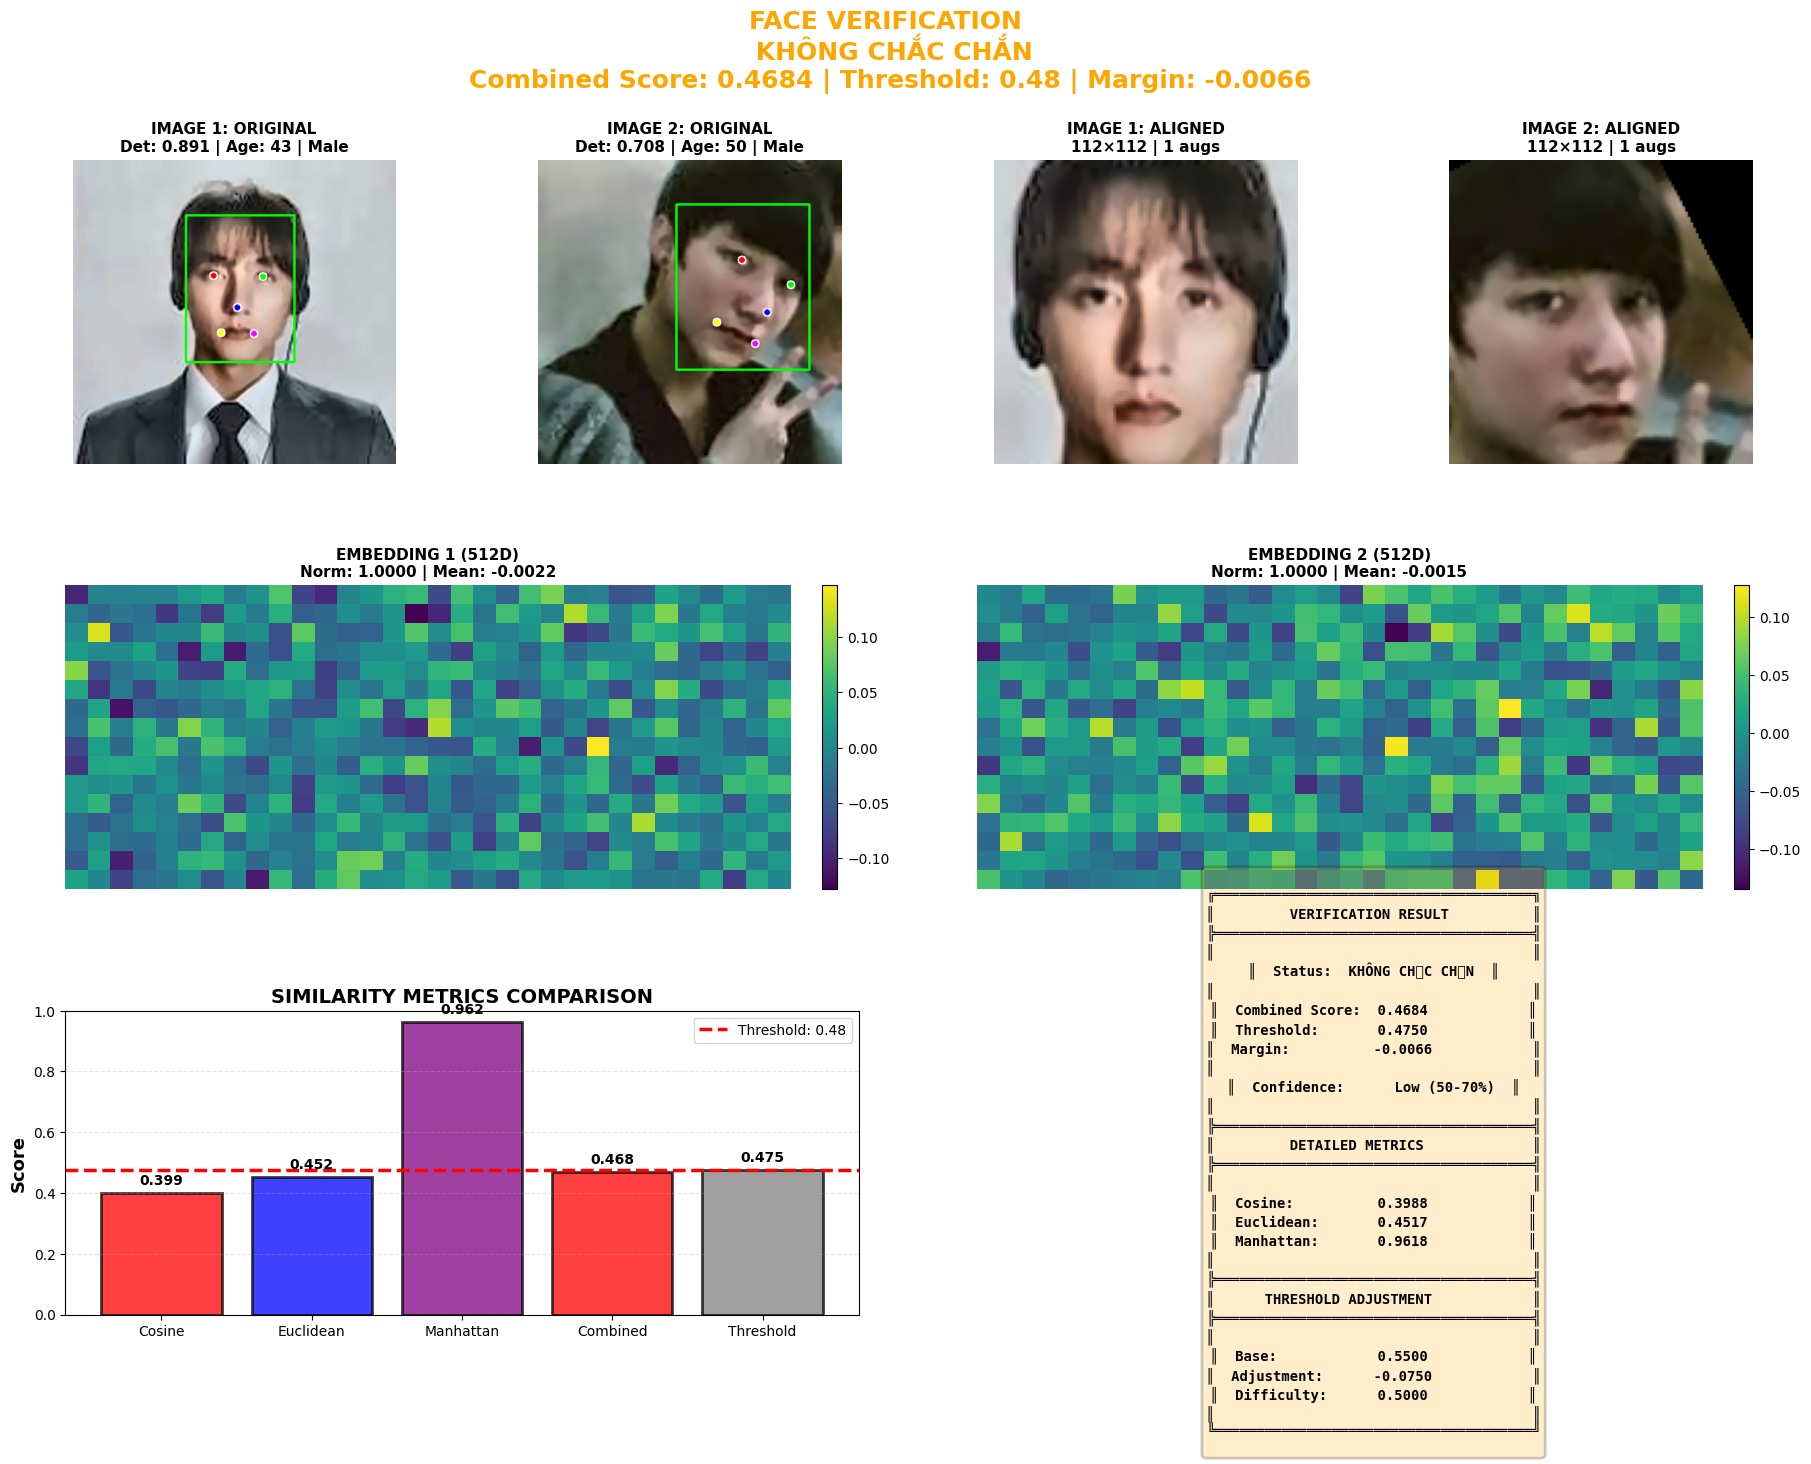


 HOÀN THÀNH VERIFICATION PIPELINE

FINAL SUMMARY
                              

 VERIFIED: NO ✗
 Combined Score: 0.4684
 Threshold: 0.48
 Margin: -0.0066
 Confidence: Low (50-70%)

💡 RECOMMENDATION:
   → Khác người hoặc cần chụp lại


In [6]:




# ============================================
# MODULE 5: MAIN 
# ============================================

def verify_faces_full_pipeline(img1_path: str, img2_path: str,
                                base_threshold: float = 0.55,
                                alignment_mode: str = 'arcface',
                                visualize: bool = True):
    
    print("\n" + "="*70)
    print("🔧 BƯỚC 0: LOAD & PREPROCESS")
    print("="*70)
    
    img1 = cv2.imread(img1_path)
    img2 = cv2.imread(img2_path)
    
    if img1 is None or img2 is None:
        raise ValueError("Không thể đọc ảnh!")
    
    img1_processed = preprocess_image(img1)
    img2_processed = preprocess_image(img2)
    
    img1_rgb = cv2.cvtColor(img1_processed, cv2.COLOR_BGR2RGB)
    img2_rgb = cv2.cvtColor(img2_processed, cv2.COLOR_BGR2RGB)
    
    print(f"   ✅ Image 1: {img1_rgb.shape}")
    print(f"   ✅ Image 2: {img2_rgb.shape}")
    
    
    print("\n" + "="*70)
    print("🔍 BƯỚC 1: FACE DETECTION")
    print("="*70)
    
    faces1 = app.get(img1_rgb)
    faces2 = app.get(img2_rgb)
    
    if not faces1 or len(faces1) == 0:
        raise ValueError(f"Không tìm thấy face trong ảnh 1: {img1_path}")
    if not faces2 or len(faces2) == 0:
        raise ValueError(f"Không tìm thấy face trong ảnh 2: {img2_path}")
    
    face1 = faces1[0]
    face2 = faces2[0]
    
    print(f"   ✅ Image 1:")
    print(f"      - Detection score: {face1.det_score:.3f}")
    print(f"      - BBox area: {int((face1.bbox[2]-face1.bbox[0])*(face1.bbox[3]-face1.bbox[1]))} pixels")
    print(f"      - Age: {face1.age:.0f}, Gender: {'Male' if face1.gender==1 else 'Female'}")
    
    print(f"   ✅ Image 2:")
    print(f"      - Detection score: {face2.det_score:.3f}")
    print(f"      - BBox area: {int((face2.bbox[2]-face2.bbox[0])*(face2.bbox[3]-face2.bbox[1]))} pixels")
    print(f"      - Age: {face2.age:.0f}, Gender: {'Male' if face2.gender==1 else 'Female'}")
    
    
    print("\n" + "="*70)
    print(f"🔄 BƯỚC 2: FACE ALIGNMENT (Mode: {alignment_mode.upper()})")
    print("="*70)
    
    pose_names = ['Left Profile', 'Slight Left', 'Frontal', 'Slight Right', 'Right Profile']
    
    mode = 'arcface' if alignment_mode == 'arcface' else 'default'
    
    aligned1, pose_idx1, error1 = norm_crop(img1_rgb, landmark=face1.kps, 
                                             image_size=112, mode=mode)
    aligned2, pose_idx2, error2 = norm_crop(img2_rgb, landmark=face2.kps,
                                             image_size=112, mode=mode)
    
    if mode == 'arcface':
        print(f"   ✅ Image 1: Aligned to ArcFace template (error: {error1:.2f})")
        print(f"   ✅ Image 2: Aligned to ArcFace template (error: {error2:.2f})")
    else:
        print(f"   ✅ Image 1: Best template = {pose_names[pose_idx1]} (error: {error1:.2f})")
        print(f"   ✅ Image 2: Best template = {pose_names[pose_idx2]} (error: {error2:.2f})")
    
    
    print("\n" + "="*70)
    print(" BƯỚC 3: EMBEDDING EXTRACTION (Multi-Scale)")
    print("="*70)
    
    emb1, pose_info1, n_aug1 = extract_embedding_advanced(img1_rgb, face1, alignment_mode)
    emb2, pose_info2, n_aug2 = extract_embedding_advanced(img2_rgb, face2, alignment_mode)
    
    print(f"    Image 1:")
    print(f"      - Embedding shape: {emb1.shape}")
    print(f"      - Augmentations: {n_aug1}")
    print(f"      - Scales used: {pose_info1['sizes']}")
    
    print(f"   ✅ Image 2:")
    print(f"      - Embedding shape: {emb2.shape}")
    print(f"      - Augmentations: {n_aug2}")
    print(f"      - Scales used: {pose_info2['sizes']}")
    
    
    print("\n" + "="*70)
    print(" BƯỚC 4: SIMILARITY METRICS")
    print("="*70)
    
    metrics = compute_similarity_metrics(emb1, emb2)
    
    print(f"    Cosine Similarity: {metrics['cosine']:.4f}")
    print(f"    Euclidean Similarity: {metrics['euclidean']:.4f} (dist: {metrics['euclidean_dist']:.4f})")
    print(f"    Manhattan Similarity: {metrics['manhattan']:.4f} (dist: {metrics['manhattan_dist']:.4f})")
    print(f"    Combined Score: {metrics['combined']:.4f}")
    
    
    print("\n" + "="*70)
    print(" BƯỚC 5: ADAPTIVE THRESHOLD")
    print("="*70)
    
    threshold, adjustment, difficulty = adaptive_threshold(pose_info1, pose_info2, base_threshold)
    
    print(f"   ✅ Base threshold: {base_threshold:.2f}")
    print(f"   ✅ Pose difficulty: {difficulty:.2f} (0=easy, 1=hard)")
    print(f"   ✅ Adjustment: {adjustment:+.2f}")
    print(f"   ✅ Final threshold: {threshold:.2f}")
    
    
    print("\n" + "="*70)
    print(" BƯỚC 6: VERIFICATION DECISION")
    print("="*70)
    
    verified = metrics['combined'] > threshold
    margin = metrics['combined'] - threshold
    
    if metrics['combined'] > threshold + 0.15:
        status = " CHẮC CHẮN CÙNG NGƯỜI"
        confidence = "Very High (>95%)"
        color = 'green'
    elif metrics['combined'] > threshold + 0.05:
        status = " CÓ THỂ CÙNG NGƯỜI"
        confidence = "High (85-95%)"
        color = 'green'
    elif metrics['combined'] > threshold:
        status = " CÙNG NGƯỜI "
        confidence = "Medium (70-85%)"
        color = 'orange'
    elif metrics['combined'] > threshold - 0.05:
        status = " KHÔNG CHẮC CHẮN"
        confidence = "Low (50-70%)"
        color = 'orange'
    else:
        status = " KHÁC NGƯỜI"
        confidence = "Very Low (<50%)"
        color = 'red'
    
    print(f"    STATUS: {status}")
    print(f"    Score: {metrics['combined']:.4f}")
    print(f"    Threshold: {threshold:.2f}")
    print(f"    Margin: {margin:+.4f}")
    print(f"    Confidence: {confidence}")
    
    
    details = {
        'face1': {
            'det_score': face1.det_score,
            'age': face1.age,
            'gender': 'Male' if face1.gender == 1 else 'Female',
            'bbox_area': int((face1.bbox[2]-face1.bbox[0])*(face1.bbox[3]-face1.bbox[1])),
            'pose_info': pose_info1,
            'n_augmentations': n_aug1
        },
        'face2': {
            'det_score': face2.det_score,
            'age': face2.age,
            'gender': 'Male' if face2.gender == 1 else 'Female',
            'bbox_area': int((face2.bbox[2]-face2.bbox[0])*(face2.bbox[3]-face2.bbox[1])),
            'pose_info': pose_info2,
            'n_augmentations': n_aug2
        },
        'threshold': {
            'base': base_threshold,
            'adjustment': adjustment,
            'final': threshold,
            'difficulty': difficulty
        },
        'decision': {
            'status': status,
            'verified': verified,
            'margin': margin,
            'confidence': confidence
        }
    }
    
    
    if visualize:
        visualize_full_results(
            img1_rgb, img2_rgb, aligned1, aligned2,
            face1, face2, emb1, emb2,
            metrics, threshold, details, status, color
        )
    
    
    print("\n" + "="*70)
    print(" HOÀN THÀNH VERIFICATION PIPELINE")
    print("="*70 + "\n")
    
    return verified, metrics, details


# ============================================
# MODULE 6: VISUALIZATION 
# ============================================

def visualize_full_results(img1, img2, aligned1, aligned2,
                           face1, face2, emb1, emb2,
                           metrics, threshold, details, status, color):
    
    fig = plt.figure(figsize=(22, 15))
    gs = fig.add_gridspec(3, 4, hspace=0.4, wspace=0.35)
    
    fig.suptitle(f'FACE VERIFICATION \n{status}\n'
                 f'Combined Score: {metrics["combined"]:.4f} | '
                 f'Threshold: {threshold:.2f} | '
                 f'Margin: {metrics["combined"]-threshold:+.4f}',
                 fontsize=18, fontweight='bold', color=color)
    
    
    # ===== ROW 1: ORIGINAL + KEYPOINTS ( BỎ TEXT LABELS) =====
    ax1 = fig.add_subplot(gs[0, 0])
    img1_viz = img1.copy()
    bbox1 = face1.bbox.astype(int)
    cv2.rectangle(img1_viz, tuple(bbox1[:2]), tuple(bbox1[2:]), (0,255,0), 4)
    
    kp_colors = [(255,0,0), (0,255,0), (0,0,255), (255,255,0), (255,0,255)]
    
    #  CHỈ VẼ KEYPOINTS - KHÔNG VẼ TEXT
    for kp, color_kp in zip(face1.kps, kp_colors):
        cv2.circle(img1_viz, tuple(kp.astype(int)), 7, color_kp, -1)
        cv2.circle(img1_viz, tuple(kp.astype(int)), 8, (255,255,255), 2)
        
    ax1.imshow(img1_viz)
    ax1.set_title(f'IMAGE 1: ORIGINAL\n'
                  f'Det: {face1.det_score:.3f} | '
                  f'Age: {face1.age:.0f} | '
                  f'{details["face1"]["gender"]}',
                  fontsize=11, fontweight='bold')
    ax1.axis('off')
    
    
    ax2 = fig.add_subplot(gs[0, 1])
    img2_viz = img2.copy()
    bbox2 = face2.bbox.astype(int)
    cv2.rectangle(img2_viz, tuple(bbox2[:2]), tuple(bbox2[2:]), (0,255,0), 4)
    
    # ⭐ CHỈ VẼ KEYPOINTS - KHÔNG VẼ TEXT
    for kp, color_kp in zip(face2.kps, kp_colors):
        cv2.circle(img2_viz, tuple(kp.astype(int)), 7, color_kp, -1)
        cv2.circle(img2_viz, tuple(kp.astype(int)), 8, (255,255,255), 2)
    
    ax2.imshow(img2_viz)
    ax2.set_title(f'IMAGE 2: ORIGINAL\n'
                  f'Det: {face2.det_score:.3f} | '
                  f'Age: {face2.age:.0f} | '
                  f'{details["face2"]["gender"]}',
                  fontsize=11, fontweight='bold')
    ax2.axis('off')
    
    
    # ===== ROW 1 COL 3-4: ALIGNED FACES =====
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.imshow(aligned1)
    ax3.set_title(f'IMAGE 1: ALIGNED\n'
                  f'112×112 | {details["face1"]["n_augmentations"]} augs',
                  fontsize=11, fontweight='bold')
    ax3.axis('off')
    
    ax4 = fig.add_subplot(gs[0, 3])
    ax4.imshow(aligned2)
    ax4.set_title(f'IMAGE 2: ALIGNED\n'
                  f'112×112 | {details["face2"]["n_augmentations"]} augs',
                  fontsize=11, fontweight='bold')
    ax4.axis('off')
    
    
    # ===== ROW 2: EMBEDDINGS =====
    ax5 = fig.add_subplot(gs[1, 0:2])
    emb1_map = emb1.reshape(16, 32)
    im1 = ax5.imshow(emb1_map, cmap='viridis', aspect='auto')
    ax5.set_title(f'EMBEDDING 1 (512D)\n'
                  f'Norm: {np.linalg.norm(emb1):.4f} | '
                  f'Mean: {np.mean(emb1):.4f}',
                  fontsize=11, fontweight='bold')
    ax5.axis('off')
    plt.colorbar(im1, ax=ax5, fraction=0.046, pad=0.04)
    
    ax6 = fig.add_subplot(gs[1, 2:4])
    emb2_map = emb2.reshape(16, 32)
    im2 = ax6.imshow(emb2_map, cmap='viridis', aspect='auto')
    ax6.set_title(f'EMBEDDING 2 (512D)\n'
                  f'Norm: {np.linalg.norm(emb2):.4f} | '
                  f'Mean: {np.mean(emb2):.4f}',
                  fontsize=11, fontweight='bold')
    ax6.axis('off')
    plt.colorbar(im2, ax=ax6, fraction=0.046, pad=0.04)
    
    
    # ===== ROW 3 COL 1: SIMILARITY METRICS =====
    ax7 = fig.add_subplot(gs[2, 0:2])
    
    metric_names = ['Cosine', 'Euclidean', 'Manhattan', 'Combined', 'Threshold']
    metric_values = [
        metrics['cosine'],
        metrics['euclidean'],
        metrics['manhattan'],
        metrics['combined'],
        threshold
    ]
    metric_colors = [
        'green' if metrics['cosine'] > threshold else 'red',
        'blue',
        'purple',
        'green' if metrics['combined'] > threshold else 'red',
        'gray'
    ]
    
    bars = ax7.bar(metric_names, metric_values, color=metric_colors,
                   alpha=0.75, edgecolor='black', linewidth=2)
    ax7.axhline(y=threshold, color='red', linestyle='--', linewidth=2.5,
                label=f'Threshold: {threshold:.2f}')
    ax7.set_ylim([0, 1])
    ax7.set_ylabel('Score', fontsize=13, fontweight='bold')
    ax7.set_title('SIMILARITY METRICS COMPARISON', fontsize=14, fontweight='bold')
    ax7.legend(fontsize=10)
    ax7.grid(axis='y', alpha=0.3, linestyle='--')
    
    for bar, val in zip(bars, metric_values):
        ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')
    
    
    # ===== ROW 3 COL 2: DECISION INFO =====
    ax8 = fig.add_subplot(gs[2, 2:4])
    ax8.axis('off')
    
    decision_text = f"""
╔══════════════════════════════════════╗
║         VERIFICATION RESULT          ║
╠══════════════════════════════════════╣
║                                      ║
║  Status: {details['decision']['status'][:20]}  ║
║                                      ║
║  Combined Score:  {metrics['combined']:.4f}            ║
║  Threshold:       {threshold:.4f}            ║
║  Margin:          {metrics['combined']-threshold:+.4f}            ║
║                                      ║
║  Confidence:      {details['decision']['confidence'][:20]}  ║
║                                      ║
╠══════════════════════════════════════╣
║         DETAILED METRICS             ║
╠══════════════════════════════════════╣
║                                      ║
║  Cosine:          {metrics['cosine']:.4f}            ║
║  Euclidean:       {metrics['euclidean']:.4f}            ║
║  Manhattan:       {metrics['manhattan']:.4f}            ║
║                                      ║
╠══════════════════════════════════════╣
║      THRESHOLD ADJUSTMENT            ║
╠══════════════════════════════════════╣
║                                      ║
║  Base:            {details['threshold']['base']:.4f}            ║
║  Adjustment:      {details['threshold']['adjustment']:+.4f}            ║
║  Difficulty:      {details['threshold']['difficulty']:.4f}            ║
║                                      ║
╚══════════════════════════════════════╝
"""
    
    ax8.text(0.5, 0.5, decision_text, ha='center', va='center',
             fontsize=10, family='monospace', fontweight='bold',
             bbox=dict(boxstyle='round', facecolor=color, alpha=0.2, edgecolor='black', linewidth=2))
    
    
    plt.savefig('verification_full_results.png', dpi=150, bbox_inches='tight')
    print(f"\n Saved visualization: verification_full_results.png")
    plt.show()


# ============================================
# USAGE
# ============================================

if __name__ == "__main__":
    
    image1 = r"C:\Users\huy.trinh1\Downloads\download (6).jpg"
    image2 = r"C:\Users\huy.trinh1\Downloads\download (3).jpg"
    
    try:
        
        print("MODE: ARCFACE (Fast & Standard)")
        print(" "*30)
        
        verified, metrics, details = verify_faces_full_pipeline(
            image1, image2,
            base_threshold=0.55,
            alignment_mode='arcface',
            visualize=True
        )
        
        
        print("FINAL SUMMARY")
        print(" "*30 + "\n")
        
        print(f" VERIFIED: {'YES ✓' if verified else 'NO ✗'}")
        print(f" Combined Score: {metrics['combined']:.4f}")
        print(f" Threshold: {details['threshold']['final']:.2f}")
        print(f" Margin: {metrics['combined'] - details['threshold']['final']:+.4f}")
        print(f" Confidence: {details['decision']['confidence']}")
        
        print(f"\n💡 RECOMMENDATION:")
        if metrics['combined'] > 0.70:
            print(f"   → Chắc chắn 100% cùng người")
        elif metrics['combined'] > 0.60:
            print(f"   → Rất có thể cùng người (>90%)")
        elif metrics['combined'] > 0.50:
            print(f"   → Có thể cùng người (70-90%)")
        else:
            print(f"   → Khác người hoặc cần chụp lại")
        
    except Exception as e:
        print(f"\n LỖI: {e}")
        import traceback
        traceback.print_exc()
